In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import os

properties = ["ehull", "formation_energy_peratom", "magmom_outcar","spillage", "mbj_bandgap", "Tc_supercon", "slme"]
for p in properties:
    # df = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv")
    path = f"pred/alignn_bert-base-uncased_robo_prop_{names[i]}_pred_otf.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)

    # df = pd.read_csv("pred/alignn_matbert-base-cased_robo_prop_Tc_supercon_pred_otf.csv")

    # df = pd.read_csv("pred/atomgpt_new/alignn_bert-base-uncased_robo_prop_spillage_pred_otf.csv")
    # df = pd.read_csv(f"pred/alignn_bert-base-uncased_robo_prop_spillage_pred_otf.csv")
    # Specify the column names
        true_col = 'labels'     # Replace with your actual column name for ground truth
        pred_col = 'predictions'     # Replace with your actual column name for predictions

        # Compute MAE
        mae = mean_absolute_error(df[true_col], df[pred_col])
    print(f"{names[i]} Mean Absolute Error (MAE): {mae:.6f}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

properties = ["ehull", "formation_energy_peratom", "magmom_outcar","spillage", "mbj_bandgap", "Tc_supercon", "slme"]
for p in properties:
    df_tf = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    df_tf["labels_tf"] = df_tf["labels"]
    df_tf['predictions_tf'] = df_tf['predictions']
    df_tf.drop(columns=["labels", 'predictions','ids_test'], inplace=True)
    df_pt = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv")
    df_pt["labels_pt"] = df_pt["labels"]
    df_pt['predictions_pt'] = df_pt['predictions']

    df_pt.drop(columns=["labels", "predictions"], inplace=True)
    df_all = pd.concat([df_tf, df_pt], axis=1)

    # print(df_all[df_all['labels_tf'] != df_all['labels_pt']][["labels_tf", "labels_pt"]])

    # Melt into long format
    df_long = df_all.melt(var_name="Model", value_name="Predictions")

    # Ensure column is float (just in case)
    df_long["Predictions"] = pd.to_numeric(df_long["Predictions"], errors='coerce')

    # Plot
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="Model", y="Predictions", data=df_long, palette={"predictions_tf": "blue", "predictions_pt": "orange"})
    plt.title(f"Grouped Box Plot for Predictions ({p})")
    plt.ylabel("Prediction Value")
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()


    

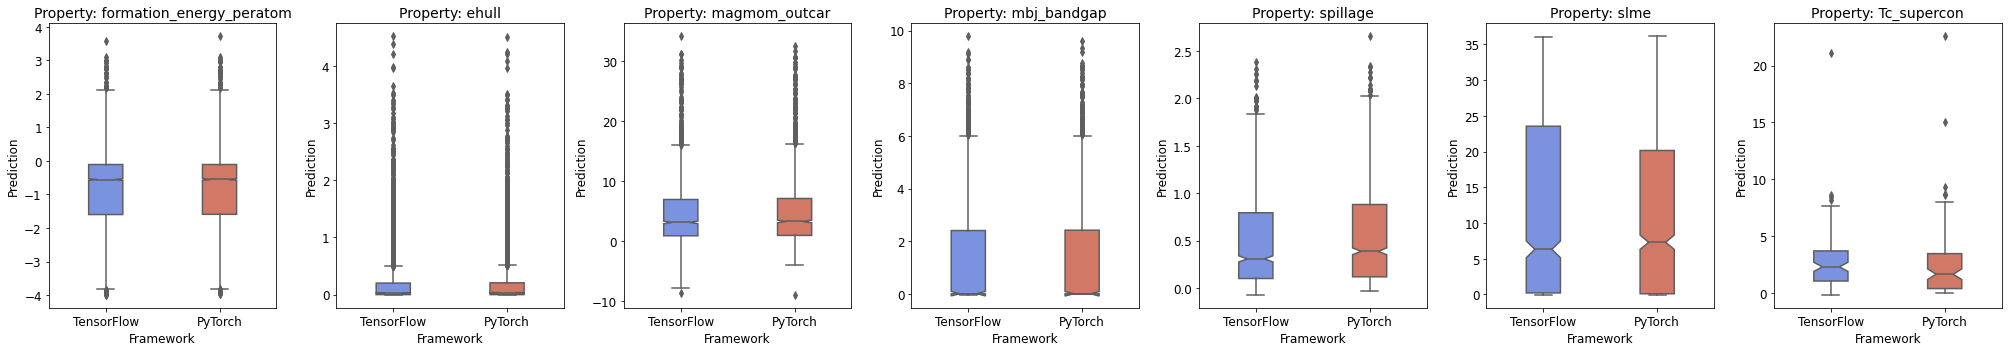

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

n_props = len(properties)
n_cols = 7  # you can change this based on layout preference
n_rows = (n_props + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows), squeeze=False)

for idx, p in enumerate(properties):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]
    
    # Load and prepare TensorFlow predictions
    df_tf = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    df_tf["Framework"] = "TensorFlow"
    df_tf["Prediction"] = df_tf["predictions"].astype(float)

    # Load and prepare PyTorch predictions
    df_pt = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv")
    df_pt["Framework"] = "PyTorch"
    df_pt["Prediction"] = df_pt["predictions"].astype(float)
    if p == "magmom_outcar":
        df_tf  = df_tf[df_tf["labels"] != 0]
        df_pt  = df_pt[df_pt["labels"] != 0]
    # Combine into one DataFrame for this property
    df_plot = pd.concat([df_tf[["Framework", "Prediction"]],
                         df_pt[["Framework", "Prediction"]]], ignore_index=True)

    # Plot
    sns.boxplot(x="Framework", y="Prediction", data=df_plot,
                palette={"PyTorch": "#e36c55", "TensorFlow": "#6a8bef"}, ax=ax, notch=True, width=0.3)
    ax.set_title(f"Property: {p}", fontsize=14)
    ax.set_xlabel("Framework", fontsize=12)
    ax.set_ylabel("Prediction", fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

# Remove unused subplots if total < rows * cols
for i in range(n_props, n_rows * n_cols):
    fig.delaxes(axes[i // n_cols][i % n_cols])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

properties = ["formation_energy_peratom", "ehull", "magmom_outcar", "mbj_bandgap", "spillage", "slme", "Tc_supercon"]
n_props = len(properties)
n_cols = 1  # box plot and scatter plot per row
n_rows = n_props  # one property per row

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 4 * n_rows), squeeze=False)

for idx, p in enumerate(properties):
    ax_box = axes[idx][0]
    # ax_parity = axes[idx][1]

    # Load TensorFlow predictions
    df_tf = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    df_tf["Framework"] = "TensorFlow"
    df_tf["Prediction"] = df_tf["predictions"].astype(float)

    # Load PyTorch predictions
    df_pt = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv")
    df_pt["Framework"] = "PyTorch"
    df_pt["Prediction"] = df_pt["predictions"].astype(float)

    if p == "magmom_outcar":
        df_tf = df_tf[df_tf["labels"] != 0]
        df_pt = df_pt[df_pt["labels"] != 0]

    # Combine data for box plot
    df_plot = pd.concat([df_tf[["Framework", "Prediction"]],
                         df_pt[["Framework", "Prediction"]]], ignore_index=True)

    # --- Box Plot ---
    sns.boxplot(x="Framework", y="Prediction", data=df_plot,
                palette={"PyTorch": "#e36c55", "TensorFlow": "#6a8bef"},
                ax=ax_box, notch=True, width=0.3)
    ax_box.set_title(f"Box Plot - {p}", fontsize=14)
    ax_box.set_xlabel("Framework", fontsize=12)
    ax_box.set_ylabel("Prediction", fontsize=12)
    ax_box.tick_params(axis='both', labelsize=10)



plt.tight_layout()
plt.show()

#### Framework-level Comparison

mbj_bandgap Mean Absolute Deviation (MAD): 0.1172
mbj_bandgap Tensorflow Mean Absolute Error (MAE): 0.2516
mbj_bandgap PyTorch Mean Absolute Error (MAE): 0.2453


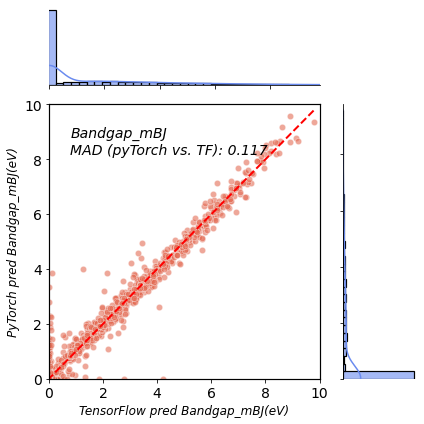

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# properties = ["formation_energy_peratom", "ehull", "magmom_outcar", "mbj_bandgap", "spillage", "slme", "Tc_supercon"]
properties = ["mbj_bandgap"]
# names = ["Formation Energy", "Energy above the Hull", "Magnetic Moment", "Bandgap_mBJ", "Spillage", "SLME", "Tc_Supercon"]
names = ["Bandgap_mBJ"]
# units = ['eV/atom', 'eV/atom', 'μB', 'eV', '', '%', 'K']
units = ['eV']

for i, p in enumerate(properties):
    # Load predictions
    df_tf = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    df_pt = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv")

    # Optional filtering
    # if p == "magmom_outcar":
    #     mask = df_tf["labels"] != 0
    #     df_tf = df_tf[mask]
    #     df_pt = df_pt[mask]

    # Add predictions
    df = pd.DataFrame({
        "TF": df_tf["predictions"].astype(float),
        "PT": df_pt["predictions"].astype(float)
    })
    mad_value = np.mean(np.abs(df["TF"] - df["PT"]))
    tf_mae_value = np.mean(np.abs(df_tf["predictions"] - df_tf["labels"]))
    pt_mae_value = np.mean(np.abs(df_pt["predictions"] - df_pt["labels"]))  
    print(f"{p} Mean Absolute Deviation (MAD): {mad_value:.4f}")
    print(f"{p} Tensorflow Mean Absolute Error (MAE): {tf_mae_value:.4f}")
    print(f"{p} PyTorch Mean Absolute Error (MAE): {pt_mae_value:.4f}")
    # Create JointGrid
    g = sns.JointGrid(data=df, x="TF", y="PT", height=6, ratio=3)

    # Central scatter plot
    g.plot_joint(sns.scatterplot, color="#e36c55", alpha=0.6, s=40, marker='o')

    # Add y = x reference line
    min_val = min(df["TF"].min(), df["PT"].min())
    max_val = max(df["TF"].max(), df["PT"].max())
    g.ax_joint.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

    g.ax_joint.set_xlim(min_val, max_val)
    g.ax_joint.set_ylim(min_val, max_val)



    # Force identical ticks
    ticks = g.ax_joint.get_xticks()
    if p in ["Tc_supercon", "spillage", "mbj_bandgap", "slme"]:
        # Force first tick to be zero (or start from zero if zero is in the list)
        ticks = np.array(ticks)
        zero_index = np.where(ticks == 0)[0]
        if len(zero_index) > 0:
            ticks = ticks[zero_index[0]:]  # trim to start from zero
        g.ax_joint.set_xlim(0, max_val)
        g.ax_joint.set_ylim(0, max_val)
    g.ax_joint.set_xticks(ticks)
    g.ax_joint.set_yticks(ticks)  # optional but ensures both are aligned

    # Marginal histograms
    # After g.plot_marginals(...)
    g.plot_marginals(sns.histplot, color="#6a8bef", alpha=0.6, kde=True, linewidth=1.2, bins=35)

    # Labels and title
    if p == "spillage":
        g.set_axis_labels(f"TensorFlow pred {names[i]}", f"PyTorch pred {names[i]}", fontsize=12, fontstyle='italic')
    else:
        g.set_axis_labels(f"TensorFlow pred {names[i]}({units[i]})", f"PyTorch pred {names[i]}({units[i]})", fontsize=12, fontstyle='italic')
    # g.ax_joint.set_title(f"Parity Plot with Histograms - {p}", fontsize=14)
    g.ax_joint.tick_params(labelsize=14)

    g.ax_joint.text(0.08, 0.92, f"{names[i]}\nMAD (pyTorch vs. TF): {mad_value:.3f}",
                    transform=g.ax_joint.transAxes,
                    ha='left', va='top',
                    fontsize=14, fontstyle='italic')

    # Enable borders (spines) for all axes
    for spine in g.ax_joint.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    # for spine in g.ax_marg_x.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(1.2)

    # for spine in g.ax_marg_y.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(1.2)
    plt.tight_layout()
    plt.savefig(f"deterministics/tf_pytorch_parity_plot_{p}.png", dpi=500, bbox_inches='tight')
    
    plt.show()

<Figure size 360x360 with 0 Axes>

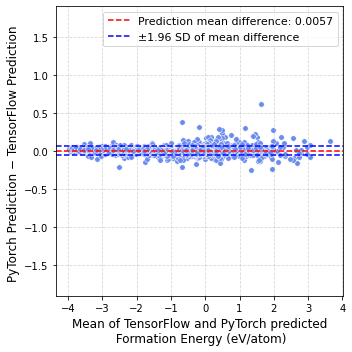

<Figure size 360x360 with 0 Axes>

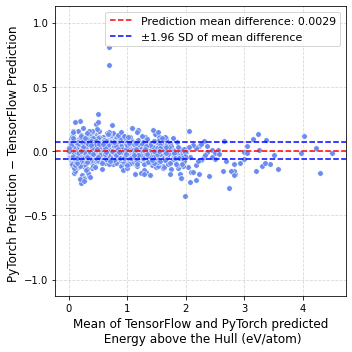

<Figure size 360x360 with 0 Axes>

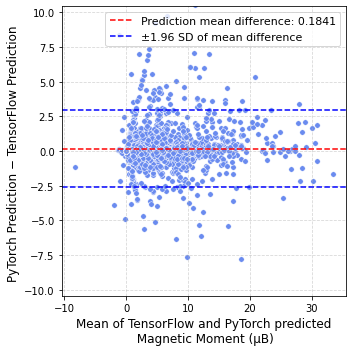

<Figure size 360x360 with 0 Axes>

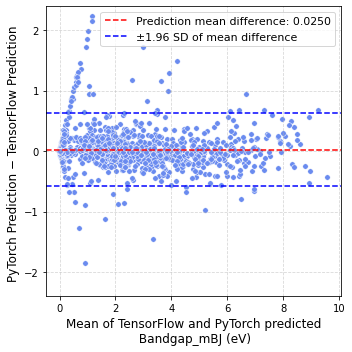

<Figure size 374.4x360 with 0 Axes>

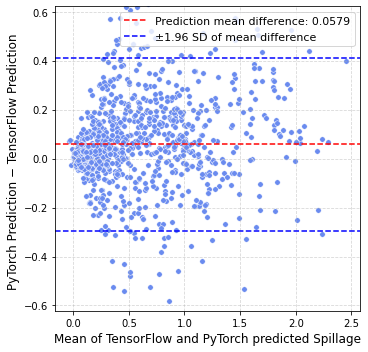

<Figure size 360x360 with 0 Axes>

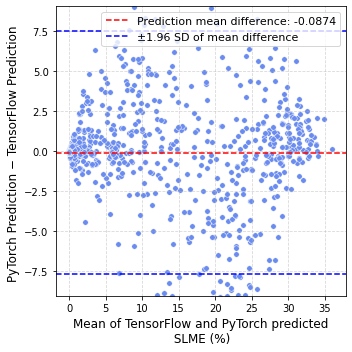

<Figure size 360x360 with 0 Axes>

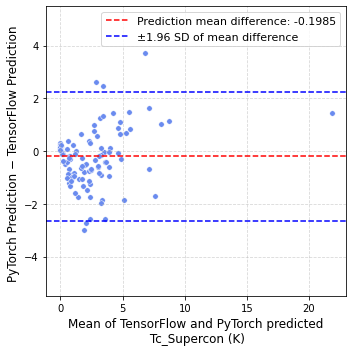

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

properties = ["formation_energy_peratom", "ehull", "magmom_outcar", "mbj_bandgap", "spillage", "slme", "Tc_supercon"]
names = ["Formation Energy", "Energy above the Hull", "Magnetic Moment", "Bandgap_mBJ", "Spillage", "SLME", "Tc_Supercon"]
units = ['eV/atom', 'eV/atom', 'μB', 'eV', '', '%', 'K']

for i, p in enumerate(properties):
    # Load predictions

    df_tf = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    df_pt = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv")

    # Optional filtering
    if p == "magmom_outcar":
        mask = df_tf["labels"] != 0
        df_tf = df_tf[mask]
        df_pt = df_pt[mask]

    # Add predictions
    df = pd.DataFrame({
        "TF": df_tf["predictions"].astype(float),
        "PT": df_pt["predictions"].astype(float)
    })
    mad_value = np.mean(np.abs(df["TF"] - df["PT"]))

    # --- Bland–Altman Plot ---
    mean_pred = (df["TF"] + df["PT"]) / 2
    diff = df["PT"] - df["TF"]
    mean_diff = np.mean(diff)
    std_diff = np.std(diff)

    if p == "spillage":
        plt.figure(figsize=(5.2, 5))
    else:
        plt.figure(figsize=(5, 5))
    pred_range = np.max(mean_pred) - np.min(mean_pred)
    ylim_max = 0.25 * pred_range

    if p == "spillage":
        plt.figure(figsize=(5.2, 5))
    else:
        plt.figure(figsize=(5, 5))
    plt.scatter(mean_pred, diff, color='#6a8bef', alpha=1, s=30, edgecolors='white', linewidths=0.5, marker='o')
    plt.axhline(mean_diff, color='red', linestyle='--', linewidth=1.5, label=f'Prediction mean difference: {mean_diff:.4f}')
    plt.axhline(mean_diff + 1.96 * std_diff, color="blue", linestyle='--', linewidth=1.5, label='±1.96 SD of mean difference')
    plt.axhline(mean_diff - 1.96 * std_diff, color="blue", linestyle='--', linewidth=1.5)
    plt.ylim(-ylim_max, ylim_max)

    # plt.title(f"Bland–Altman Plot: {p}", fontsize=12)
    if p == "spillage":
         plt.xlabel(f"Mean of TensorFlow and PyTorch predicted {names[i]}", fontsize=12)
    else:
        plt.xlabel(f"Mean of TensorFlow and PyTorch predicted\n {names[i]} ({units[i]})", fontsize=12)
    plt.ylabel("PyTorch Prediction − TensorFlow Prediction ", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11, loc='upper right')
    plt.tight_layout()
    plt.savefig(f"deterministics/tf_pytorch_bland_altman_plot_{p}.png", dpi=500, bbox_inches='tight')
    plt.show()

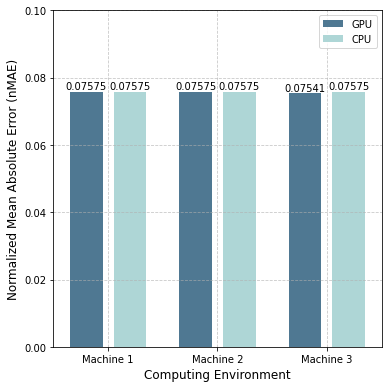

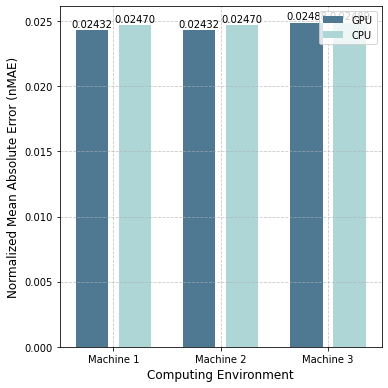

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Example data
for p in ["Tc_supercon", "mbj_bandgap", ]:
    if p == "Tc_supercon":
        MAEs = [2.037844, 2.037906, 2.037844, 2.037906, 2.028638, 2.037905]
    else:
        MAEs = [0.241553, 0.245349, 0.241553, 0.245349, 0.247155, 0.247286]
    data = {
        'System': ['Machine 1', 'Machine 1', 'Machine 2', 'Machine 2', 'Machine 3', 'Machine 3'],
        'Env': ['GPU', 'CPU', 'GPU', 'CPU', 'GPU', 'CPU'],
        'MAE': MAEs,
        'Model': ['GPU Tesla V100', 'Intel(R) Xeon(R) Gold 6126 CPU', 'GPU Tesla V100', 'Intel(R) Xeon(R) Gold 6126 CPU', 'Tesla T4', 'Intel(R) Xeon(R) CPU']
    }

    df_tf = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    actual_max = df_tf["labels"].max()
    actual_min = df_tf["labels"].min()
    actual_range = actual_max - actual_min
    df = pd.DataFrame(data)
    df['nMAE'] = df['MAE'] / actual_range  # Normalized MAE
    # Plot
    plt.figure(figsize=(5.5, 5.5))
    # ax = sns.pointplot(data=df, x='System', y='MAE', hue='Env', dodge=0.4, join=False, palette='Set2',
    #                    markers='_', scale=2, errwidth=0)  # underscore as a flat marker
    palette = {'CPU': "#a7dddc", 'GPU': "#447b9d"}
    ax = sns.barplot(data=df, x='System', y='nMAE', hue='Env', palette=palette)

    # Customizations
    # plt.title("Tc_supercon MAE Trained CPU/GPU Across Machines\n", fontsize=14)
    plt.ylabel("Normalized Mean Absolute Error (nMAE)", fontsize=12)
    plt.xlabel("Computing Environment", fontsize=12)
    if p == "Tc_supercon":
        plt.ylim(0, 0.1)
    # plt.ylim(2.027, 2.040)
    # 
    # change position to lower left corner
    plt.legend(loc='upper right')

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add data labels
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 0.0001,
            s=f"{height:.5f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    # Change width of bars
    bar_width = 0.3 # default is around 0.8
    for bar in ax.patches:
        current_width = bar.get_width()
        diff = current_width - bar_width
        bar.set_width(bar_width)
        bar.set_x(bar.get_x() + diff / 2)  # recenter the bar

    plt.tight_layout()
    plt.savefig(f"deterministics/tc_supercon_bar.png", dpi=500)
    plt.show()

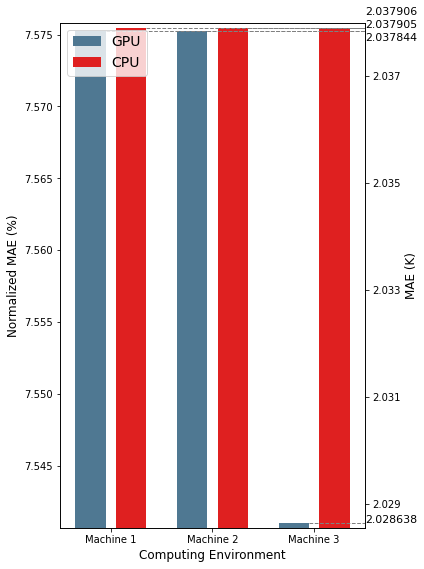

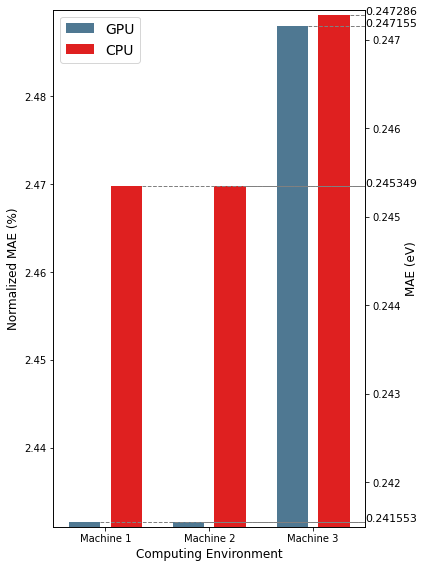

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

units = ['eV', 'K']
for p in ["Tc_supercon", "mbj_bandgap"]:
    if p == "Tc_supercon":
        MAEs = [2.037844, 2.037906, 2.037844, 2.037906, 2.028638, 2.037905]
    else:
        MAEs = [0.241553, 0.245349, 0.241553, 0.245349, 0.247155, 0.247286]

    data = {
        'System': ['Machine 1', 'Machine 1', 'Machine 2', 'Machine 2', 'Machine 3', 'Machine 3'],
        'Env': ['GPU', 'CPU', 'GPU', 'CPU', 'GPU', 'CPU'],
        'MAE': MAEs,
        'Model': ['GPU Tesla V100', 'Intel(R) Xeon(R) Gold 6126 CPU', 'GPU Tesla V100',
                  'Intel(R) Xeon(R) Gold 6126 CPU', 'Tesla T4', 'Intel(R) Xeon(R) CPU']
    }

    df_tf = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    actual_max = df_tf["labels"].max()
    actual_min = df_tf["labels"].min()
    actual_range = actual_max - actual_min

    df = pd.DataFrame(data)
    df['nMAE'] = df['MAE'] / actual_range * 100  # Normalized MAE as percentage

    # palette = {'CPU': "#a7dddc", 'GPU': "#447b9d"}
    palette = {'CPU': "red", 'GPU': "#447b9d"}

    fig, ax1 = plt.subplots(figsize=(6,8))

    # Plot normalized MAE on left axis
    ax = sns.barplot(data=df, x='System', y='nMAE', hue='Env', palette=palette, ax=ax1)
    ax1.set_ylabel("Normalized MAE (%)", fontsize=12)
    ax1.set_xlabel("Computing Environment", fontsize=12)
    ax1.tick_params(axis='y', labelsize=10)
    # ax1.grid(True, linestyle='--', alpha=0.7)

    # Calculate adaptive y-limits to enhance bar separation
    min_nmae = df['nMAE'].min()
    max_nmae = df['nMAE'].max()
    margin = 0.01 * (max_nmae - min_nmae)
    lower = max(0, min_nmae - margin)
    upper = max_nmae + margin
    ax1.set_ylim(lower, upper)

    y_offset = 0.01 * (upper - lower)  # dynamic vertical offset for label

    # Right axis: raw MAE
    ax2 = ax1.twinx()
    if p == "Tc_supercon":
        ax2.set_ylabel("MAE (K)", fontsize=12)
    else:
        ax2.set_ylabel("MAE (eV)", fontsize=12)
    lower_raw = actual_range * lower / 100
    upper_raw = actual_range * upper / 100
    ax2.set_ylim(lower_raw, upper_raw)
    if p == "Tc_supercon":
        tick_start = 2.029
        tick_step = 0.002
        tick_end = df['MAE'].max() + 0.001  # small margin

        custom_ticks = np.arange(tick_start, tick_end, tick_step)
        ax2.set_yticks(custom_ticks)
    ax2.tick_params(axis='y', labelsize=10)

    # Store original x-limits
    xlim_original = ax1.get_xlim()

    # Bar styling + annotations
    bar_width = 0.3
    # print(df)
    # for bar in ax1.patches:
    #     print(bar.get_height())
    # Reorder ax.patches to [0, 3, 1, 4, 2, 5]
    patch_order = [0, 3, 1, 4, 2, 5]
    reordered_patches = [ax.patches[i] for i in patch_order]
    for idx, (bar, mae, nmae) in enumerate(zip(reordered_patches, df['MAE'], df['nMAE'])):
        # Resize and center bars
        current_width = bar.get_width()
        diff = current_width - bar_width
        bar.set_width(bar_width)
        bar.set_x(bar.get_x() + diff / 2)

        # Dashed line from top of bar to right
        ax1.plot(
            [bar.get_x() + bar.get_width(), xlim_original[1]],
            [bar.get_height(), bar.get_height()],
            ls='--',
            color='gray',
            lw=1
        )
        if idx not in [2,3]:
            y_annot = bar.get_height()
            if p == "Tc_supercon" :
                # Adaptive vertical shift for annotation based on height

                if idx == 1:  
                    y_annot = bar.get_height() + 0.025 * (upper - lower)  # place above
                    # va = 'bottom'
                elif idx == 0:
                    y_annot = bar.get_height() - 0.02 * (upper - lower)  # place below
                    # va = 'top'

                # Raw MAE annotation at right end of dashed line
            ax1.text(
                x=xlim_original[1],
                y=y_annot,
                s=f"{mae}",
                # va=va,
                ha='left',
                fontsize=11,
                color='black'
            )

        # nMAE label above bar
        # print(nmae)
        # ax1.text(
        #     x=bar.get_x() + bar.get_width() / 2,
        #     y=bar.get_height() + y_offset,
        #     s=f"{nmae:.4f}%",
        #     ha='center',
        #     va='bottom',
        #     fontsize=11
        # )

    # Restore original x-limits
    ax1.set_xlim(xlim_original)

    # Legend and save
    # ax1.legend(
    #     loc='lower center',
    #     bbox_to_anchor=(0.9, 1.02),
    #     ncol=2,
    #     fontsize=14,
    #     frameon=False
    # )
    ax1.legend(
        loc='upper left',
        fontsize=14,
        frameon=True
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.tight_layout()
    plt.savefig(f"deterministics/{p}_bar_dual_axis.png", dpi=500)

    plt.show()

#### Cross-system Level Comparison

mbj_bandgap Mean Absolute Deviation (MAD): 0.0776
mbj_bandgap Tensorflow Mean Absolute Error (MAE): 0.2453
mbj_bandgap PyTorch Mean Absolute Error (MAE): 0.2416


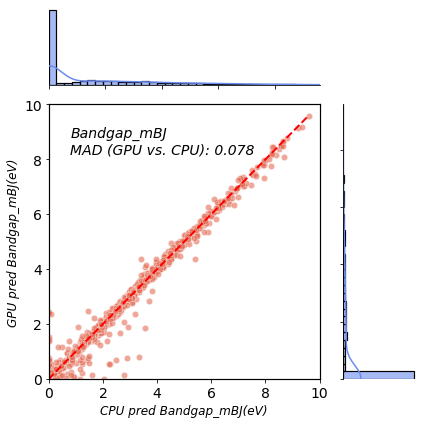

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# properties = ["formation_energy_peratom", "ehull", "magmom_outcar", "mbj_bandgap", "spillage", "slme", "Tc_supercon"]
properties = ["mbj_bandgap"]
# names = ["Formation Energy", "Energy above the Hull", "Magnetic Moment", "Bandgap_mBJ", "Spillage", "SLME", "Tc_Supercon"]
names = ["Bandgap_mBJ"]
# units = ['eV/atom', 'eV/atom', 'μB', 'eV', '', '%', 'K']
units = ['eV']

for i, p in enumerate(properties):
    # Load predictions
    df_cpu = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_mbj_bandgap_pred_otf_20250614_193231_cpu.csv", index_col=0)
    df_gpu = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_mbj_bandgap_pred_otf_20250614_184558_gpu.csv", index_col=0)

    # Optional filtering
    # if p == "magmom_outcar":
    #     mask = df_cpu["labels"] != 0
    #     df_cpu = df_cpu[mask]
    #     df_gpu = df_gpu[mask]

    # Add predictions
    df = pd.DataFrame({
        "CPU": df_cpu["predictions"].astype(float),
        "GPU": df_gpu["predictions"].astype(float)
    })
    mad_value = np.mean(np.abs(df["CPU"] - df["GPU"]))
    tf_mae_value = np.mean(np.abs(df_cpu["predictions"] - df_cpu["labels"]))
    pt_mae_value = np.mean(np.abs(df_gpu["predictions"] - df_gpu["labels"]))  
    print(f"{p} Mean Absolute Deviation (MAD): {mad_value:.4f}")
    print(f"{p} Tensorflow Mean Absolute Error (MAE): {tf_mae_value:.4f}")
    print(f"{p} PyTorch Mean Absolute Error (MAE): {pt_mae_value:.4f}")
    # Create JointGrid
    g = sns.JointGrid(data=df, x="CPU", y="GPU", height=6, ratio=3)

    # Central scatter plot
    g.plot_joint(sns.scatterplot, color="#e36c55", alpha=0.6, s=40, marker='o')

    # Add y = x reference line
    min_val = min(df["CPU"].min(), df["GPU"].min())
    max_val = max(df["CPU"].max(), df["GPU"].max())
    g.ax_joint.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

    g.ax_joint.set_xlim(min_val, max_val)
    g.ax_joint.set_ylim(min_val, max_val)



    # Force identical ticks
    ticks = g.ax_joint.get_xticks()
    if p in ["Tc_supercon", "spillage", "mbj_bandgap", "slme"]:
        # Force first tick to be zero (or start from zero if zero is in the list)
        ticks = np.array(ticks)
        zero_index = np.where(ticks == 0)[0]
        if len(zero_index) > 0:
            ticks = ticks[zero_index[0]:]  # trim to start from zero
        g.ax_joint.set_xlim(0, max_val)
        g.ax_joint.set_ylim(0, max_val)
    g.ax_joint.set_xticks(ticks)
    g.ax_joint.set_yticks(ticks)  # optional but ensures both are aligned

    # Marginal histograms
    # After g.plot_marginals(...)
    g.plot_marginals(sns.histplot, color="#6a8bef", alpha=0.6, kde=True, linewidth=1.2, bins=35)

    # Labels and title
    if p == "spillage":
        g.set_axis_labels(f"CPU pred {names[i]}", f"GPU pred {names[i]}", fontsize=12, fontstyle='italic')
    else:
        g.set_axis_labels(f"CPU pred {names[i]}({units[i]})", f"GPU pred {names[i]}({units[i]})", fontsize=12, fontstyle='italic')
    # g.ax_joint.set_title(f"Parity Plot with Histograms - {p}", fontsize=14)
    g.ax_joint.tick_params(labelsize=14)

    g.ax_joint.text(0.08, 0.92, f"{names[i]}\nMAD (GPU vs. CPU): {mad_value:.3f}",
                    transform=g.ax_joint.transAxes,
                    ha='left', va='top',
                    fontsize=14, fontstyle='italic')

    # Enable borders (spines) for all axes
    for spine in g.ax_joint.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    # for spine in g.ax_marg_x.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(1.2)

    # for spine in g.ax_marg_y.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(1.2)
    plt.tight_layout()
    plt.savefig(f"deterministics/tf_gpu_cpu_parity_plot_{p}.png", dpi=500, bbox_inches='tight')
    
    plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

properties = ["formation_energy_peratom", "ehull", "magmom_outcar", "mbj_bandgap", "spillage", "slme", "Tc_supercon"]
names = ["Formation Energy", "Energy above the Hull", "Magnetic Moment", "Bandgap_mBJ", "Spillage", "SLME", "Tc_Supercon"]
units = ['eV/atom', 'eV/atom', 'μB', 'eV', '', '%', 'K']

for i, p in enumerate(properties):
    # Load predictions

    df_cpu = pd.read_csv(f"deterministics/tensorflow/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv", index_col=0)
    df_gpu = pd.read_csv(f"deterministics/prediction_torch/alignn_matbert-base-cased_robo_prop_{p}_pred_otf.csv")

    # Optional filtering
    if p == "magmom_outcar":
        mask = df_cpu["labels"] != 0
        df_cpu = df_cpu[mask]
        df_gpu = df_gpu[mask]

    # Add predictions
    df = pd.DataFrame({
        "cpu": df_cpu["predictions"].astype(float),
        "gpu": df_gpu["predictions"].astype(float)
    })
    mad_value = np.mean(np.abs(df["cpu"] - df["gpu"]))

    # --- Bland–Altman Plot ---
    mean_pred = (df["cpu"] + df["gpu"]) / 2
    diff = df["gpu"] - df["cpu"]
    mean_diff = np.mean(diff)
    std_diff = np.std(diff)

    if p == "spillage":
        plt.figure(figsize=(5.2, 5))
    else:
        plt.figure(figsize=(5, 5))
    pred_range = np.max(mean_pred) - np.min(mean_pred)
    ylim_max = 0.25 * pred_range

    if p == "spillage":
        plt.figure(figsize=(5.2, 5))
    else:
        plt.figure(figsize=(5, 5))
    plt.scatter(mean_pred, diff, color='#6a8bef', alpha=1, s=30, edgecolors='white', linewidths=0.5, marker='o')
    plt.axhline(mean_diff, color='red', linestyle='--', linewidth=1.5, label=f'Prediction mean difference: {mean_diff:.4f}')
    plt.axhline(mean_diff + 1.96 * std_diff, color="blue", linestyle='--', linewidth=1.5, label='±1.96 SD of mean difference')
    plt.axhline(mean_diff - 1.96 * std_diff, color="blue", linestyle='--', linewidth=1.5)
    plt.ylim(-ylim_max, ylim_max)

    # plt.title(f"Bland–Altman Plot: {p}", fontsize=12)
    if p == "spillage":
         plt.xlabel(f"Mean of CPU and GPU predicted {names[i]}", fontsize=12)
    else:
        plt.xlabel(f"Mean of TensorFlow and PyTorch predicted\n {names[i]} ({units[i]})", fontsize=12)
    plt.ylabel("PyTorch Prediction − TensorFlow Prediction ", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11, loc='upper right')
    plt.tight_layout()
    plt.savefig(f"deterministics/tf_pytorch_bland_altman_plot_{p}.png", dpi=500, bbox_inches='tight')
    plt.show()